# Studies of random matrices their singular value decompositions

Construct some matrices from sampling their distributions and look at the impact of changing the distribution on the SVD. This mostly involves developing intuition for results from Random Matrix Theory.

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import math

## Some helper functions to generate matrices of interest

In [2]:
sv_bins = np.linspace(0,100,51)
sv_centers = (sv_bins[:-1] + sv_bins[1:]) / 2
sv_dx = sv_bins[1] - sv_bins[0]
w_bins = np.linspace(-30, 30, 41)
w_centers = (w_bins[:-1] + w_bins[1:]) / 2
w_dx = w_bins[1] - w_bins[0]

def generate_full_rank(d_n, mu=0, sigma=1):
    h = np.random.normal(loc=mu, scale=sigma, size=d_n*d_n)
    W_QK = h.reshape(d_n, d_n)
    _, S, _ = torch.linalg.svd(torch.tensor(W_QK))    
    P_w,_ = np.histogram(h, w_bins, density = True)
    P_s,_ = np.histogram(S, sv_bins, density = True)
    return S, torch.tensor(P_w, dtype=float), torch.tensor(P_s, dtype=float)

def generate_low_rank(d_n, d_m, mu=0, sigma=1):
    W_Q = np.random.normal(loc=mu, scale=sigma, size=d_n*d_m).reshape(d_n, d_m)
    W_K = np.random.normal(loc=mu, scale=sigma, size=d_n*d_m).reshape(d_m, d_n)
    W_QK = W_Q @ W_K
    _, S, _ = torch.linalg.svd(torch.tensor(W_QK))
    P_w,_ = np.histogram(W_QK.flatten(), w_bins, density = True)
    P_s,_ = np.histogram(S, sv_bins, density = True)
    return S, torch.tensor(P_w, dtype=float), torch.tensor(P_s, dtype=float)

def average_curves(func, n_samp=10, **kwargs):
    results = [func(**kwargs) for _ in range(n_samp)]
    x_list, y_list, z_list = zip(*results)
    x_avg = torch.stack(x_list).mean(dim=0)
    y_avg = torch.stack(y_list).mean(dim=0)
    z_avg = torch.stack(z_list).mean(dim=0)
    return (x_avg, y_avg, z_avg)

def draw_trio(func, **kwargs):
    _, axes = plt.subplots(1, 3, figsize=(12, 3))
    sv, arr, spec = average_curves(func, **kwargs)

    axes[0].plot(w_centers, arr)
    axes[0].set_xlabel('W')
    axes[0].set_ylabel('P(W)')

    axes[1].plot(sv)
    axes[1].set_xlabel('Index')
    axes[1].set_ylabel('SV')
    axes[1].set_yscale('log')

    axes[2].plot(sv_centers, spec)
    axes[2].set_xlabel('SV')
    axes[2].set_ylabel('P(SV)')
    axes[2].set_yscale('log')
    
    plt.tight_layout()
    plt.show()

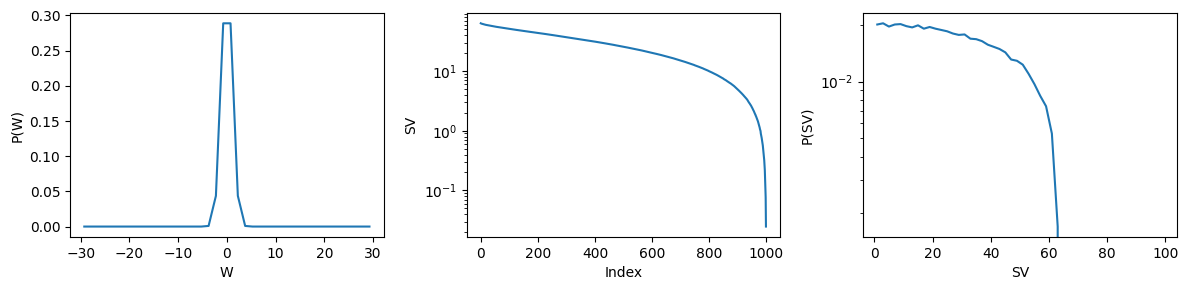

In [3]:
draw_trio(generate_full_rank, d_n=1000, n_samp=5)

## Singular value distributions and spectral densities

### Full rank - varying $\sigma$

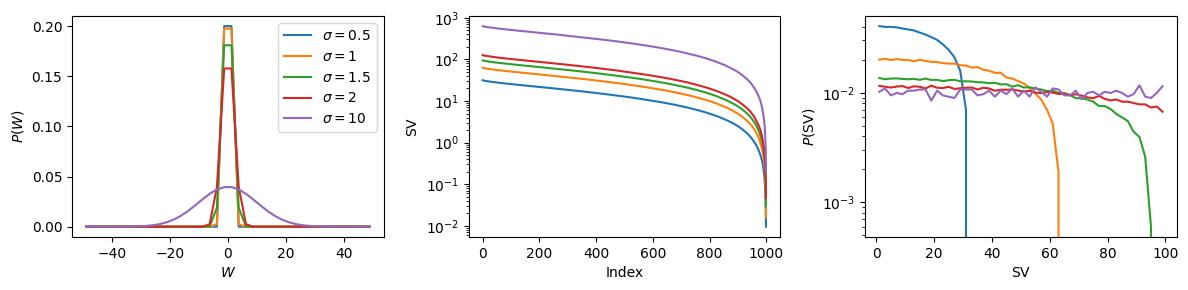

In [4]:
d_n = 1000
d_m = 500
_, axes = plt.subplots(1, 3, figsize=(12, 3))
w_bins = np.linspace(-50, 50, 41)
w_centers = (w_bins[:-1] + w_bins[1:]) / 2
w_dx = w_bins[1] - w_bins[0]

sv_bins = np.linspace(0,100,51)
sv_centers = (sv_bins[:-1] + sv_bins[1:]) / 2
sv_dx = sv_bins[1] - sv_bins[0]

h_full_rank = {}
for sigma in [0.5, 1, 1.5, 2, 10]:    
    sv, arr, spec = average_curves(generate_full_rank, d_n=d_n, sigma=sigma)

    name = f"$\sigma = {sigma}$"
    axes[0].plot(w_centers, arr, label = name)
    axes[0].set_xlabel('$W$')
    axes[0].set_ylabel('$P(W)$')
    axes[0].legend()

    axes[1].plot(sv)
    axes[1].set_xlabel('Index')
    axes[1].set_ylabel('$\mathrm{SV}$')
    axes[1].set_yscale('log')

    axes[2].plot(sv_centers, spec)
    axes[2].set_xlabel('$\mathrm{SV}$')
    axes[2].set_ylabel('$P(\mathrm{SV})$')
    axes[2].set_yscale('log')
plt.tight_layout()
plt.show()

### Low rank - varying $\sigma$ at fixed $d_n / d_m = 2$

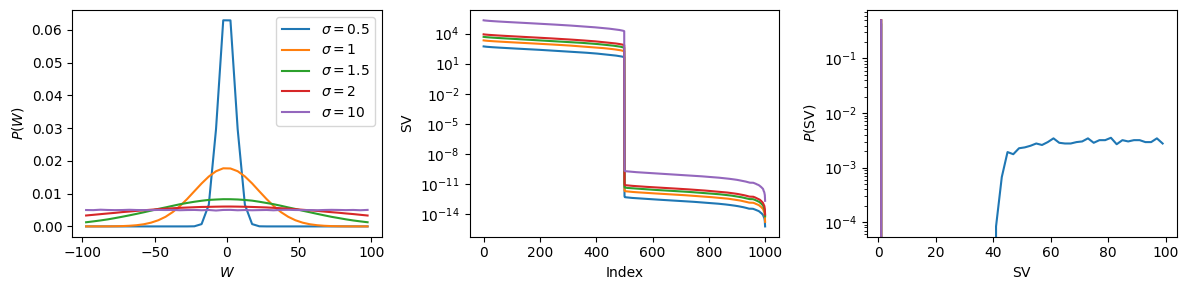

In [5]:
d_n = 1000
d_m = 500
w_bins = np.linspace(-100, 100, 41)
w_centers = (w_bins[:-1] + w_bins[1:]) / 2
w_dx = w_bins[1] - w_bins[0]

_, axes = plt.subplots(1, 3, figsize=(12, 3))
h_low_rank = {}
for sigma in [0.5, 1, 1.5, 2, 10]:    
    sv, arr, spec = average_curves(generate_low_rank, d_n=d_n, d_m=d_m, sigma=sigma)

    name = f"$\sigma = {sigma}$"
    axes[0].plot(w_centers, arr, label = name)
    axes[0].set_xlabel('$W$')
    axes[0].set_ylabel('$P(W)$')
    axes[0].legend()

    axes[1].plot(sv)
    axes[1].set_xlabel('Index')
    axes[1].set_ylabel('$\mathrm{SV}$')
    axes[1].set_yscale('log')

    axes[2].plot(sv_centers, spec)
    axes[2].set_xlabel('$\mathrm{SV}$')
    axes[2].set_ylabel('$P(\mathrm{SV})$')
    axes[2].set_yscale('log')
plt.tight_layout()
plt.show()

### Low rank - $\sigma = 1$ varying $d_n / d_m = 0.1, 0.2, \cdots 1$

Also showing full rank. 

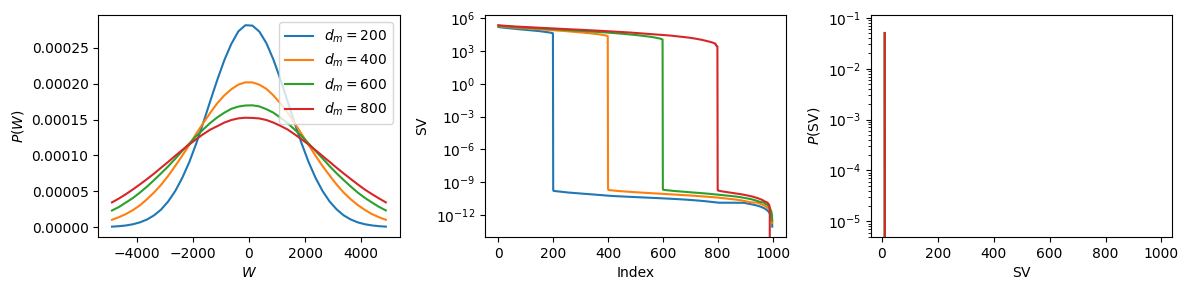

In [6]:
d_n = 1000
d_step = 200
w_bins = np.linspace(-5000, 5000, 41)
w_centers = (w_bins[:-1] + w_bins[1:]) / 2
w_dx = w_bins[1] - w_bins[0]
sv_bins = np.linspace(0,1000,51)
sv_centers = (sv_bins[:-1] + sv_bins[1:]) / 2
sv_dx = sv_bins[1] - sv_bins[0]

h_out = {}
single_count_density = 1.0 / (d_n * sv_dx)
_, axes = plt.subplots(1, 3, figsize=(12, 3))
for d_m in range(d_step, d_n + d_step - d_step, d_step):
    sv, arr, spec = average_curves(generate_low_rank, d_n=d_n, d_m=d_m, sigma=sigma)

    name = f"$d_m = {d_m}$"
    axes[0].plot(w_centers, arr, label = name)
    axes[0].set_xlabel('$W$')
    axes[0].set_ylabel('$P(W)$')
    axes[0].legend()

    axes[1].plot(sv)
    axes[1].set_xlabel('Index')
    axes[1].set_ylabel('$\mathrm{SV}$')
    axes[1].set_yscale('log')

    axes[2].plot(sv_centers, spec)
    axes[2].set_xlabel('$\mathrm{SV}$')
    axes[2].set_ylabel('$P(\mathrm{SV})$')
    axes[2].set_yscale('log')
    axes[2].set_ylim(bottom=single_count_density * 0.1) 
plt.tight_layout()
plt.show()

## Two Gaussians
Model is now $x ~ f N(0,1) + (1-f)N(\mu, \sigma)$
First we evaluate at fixed $f$, choosing $\mu ~0$ and $\sigma >> 1$. This has the effect of adding a nearly uniform component to the distribution but without the usual effects from the finite domain of the Uniform distribution.

In [7]:
def sample_mixture(d_n, mu1=0.0, sigma1=1.0, mu2=0.0, sigma2=2.0, f=0.5, binomial=False, device='cpu'):
    n = d_n*d_n
    if binomial:
        n2 = int(torch.binomial(torch.tensor(n, dtype=torch.float32), 
                            torch.tensor(float(f))).item())
    else:
        n2 = int(f * n)
    n1 = n - n2
    dev = torch.device(device)
    samples1 = torch.normal(mu1, sigma1, size=(n1,), device=dev)
    samples2 = torch.normal(mu2, sigma2, size=(n2,), device=dev)
    
    samples = torch.cat([samples1, samples2])
    samples = samples[torch.randperm(n, device=dev)]
    _, S, _ = torch.linalg.svd(samples.reshape(d_n, d_n))
    P_w,_ = np.histogram(samples, w_bins, density = True)
    P_s,_ = np.histogram(S, sv_bins, density = True)
    return S, torch.tensor(P_w, dtype=float), torch.tensor(P_s, dtype=float)

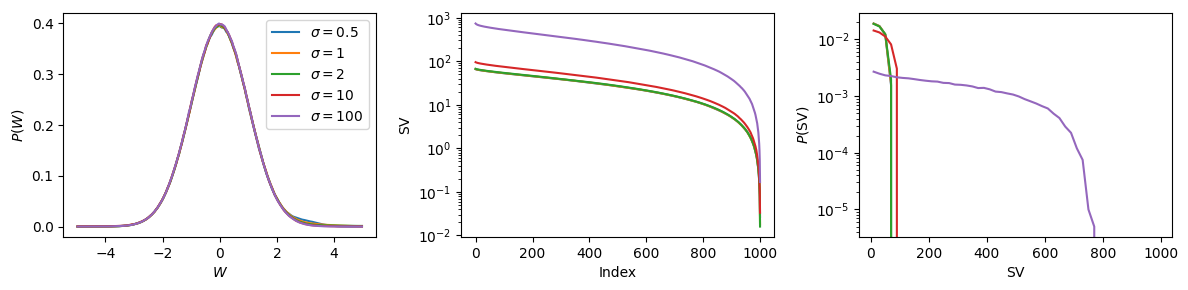

In [8]:
d_n = 1000
d_step = 200
w_bins = np.linspace(-5, 5, 201)
w_centers = (w_bins[:-1] + w_bins[1:]) / 2
w_dx = w_bins[1] - w_bins[0]
sv_bins = np.linspace(0,1000,51)
sv_centers = (sv_bins[:-1] + sv_bins[1:]) / 2
sv_dx = sv_bins[1] - sv_bins[0]

h_out = {}
single_count_density = 1.0 / (d_n * sv_dx)
_, axes = plt.subplots(1, 3, figsize=(12, 3))

for sigma in [0.5, 1, 2, 10, 100]:    
    sv, arr, spec = average_curves(sample_mixture, d_n=d_n, mu2=3, sigma2=sigma, f=0.01, binomial=True)

    name = f"$\sigma = {sigma}$"
    axes[0].plot(w_centers, arr, label = name)
    axes[0].set_xlabel('$W$')
    axes[0].set_ylabel('$P(W)$')
    axes[0].legend()

    axes[1].plot(sv)
    axes[1].set_xlabel('Index')
    axes[1].set_ylabel('$\mathrm{SV}$')
    axes[1].set_yscale('log')
    # axes[1].set_xlim(left=0, right=10)

    axes[2].plot(sv_centers, spec)
    axes[2].set_xlabel('$\mathrm{SV}$')
    axes[2].set_ylabel('$P(\mathrm{SV})$')
    axes[2].set_yscale('log')
plt.tight_layout()
plt.show()

### Nested block structures
- Nesting with self: $W = A \otimes A \otimes \cdots A$, where $A$ is a single $n\times n$ matrix multiplied $m$ times.
- Nesting with a new matrix each time: $W = A_0 \otimes A_1 \otimes \cdots A_m$ where the $A_i$'s are separate random matrices

Dimension blows up quickly, matrices are $n^{2m} \times n^{2m}$

Simplification use $A_i = \mathbf{R}(\theta_i)$. Parameterize the matrix by random angles.

In [9]:
def generate_nested_blocks(d_h, n_h, nested=False):
    # A = torch.tensor(np.random.normal(size=(d_h, d_h)))
    theta = torch.rand(1) * 2 * math.pi
    c, s = torch.cos(theta), torch.sin(theta)
    A =  torch.tensor([[c, -s], [s, c]])
    print(f"Theta 0: {theta.item():.2f}" )
    #A = torch.tensor(np.arange(d_h*d_h).reshape(d_h,d_h))
    for idx in range(n_h):
        B = A
        if nested:
            #B = torch.tensor(np.random.normal(size=(d_h, d_h)))
            theta = torch.rand(1) * 2 * math.pi
            print(f"Theta {idx}: {theta.item():.2f}" )

            c, s = torch.cos(theta), torch.sin(theta)
            A =  torch.tensor([[c, -s], [s, c]])
        A = torch.kron(A, B)

    _, S, _ = torch.linalg.svd(A)
    P_w,_ = np.histogram(A.flatten(), w_bins, density = True)
    P_s,_ = np.histogram(S, sv_bins, density = True)
    return S, torch.tensor(P_w, dtype=float), torch.tensor(P_s, dtype=float)
gnb = generate_nested_blocks(2, 3)    

Theta 0: 4.13


Theta 0: 0.61
Theta 0: 5.41
Theta 0: 4.79
Theta 0: 4.73
Theta 0: 6.13
Theta 0: 5.63
Theta 0: 5.84
Theta 0: 5.67
Theta 0: 2.06
Theta 0: 5.10
Theta 0: 0.29
Theta 0: 4.38
Theta 1: 2.76
Theta 2: 2.47
Theta 0: 1.83
Theta 0: 3.31
Theta 1: 2.83
Theta 2: 2.65
Theta 0: 3.94
Theta 0: 5.65
Theta 1: 1.93
Theta 2: 4.65
Theta 0: 6.22
Theta 0: 4.62
Theta 1: 5.26
Theta 2: 5.00
Theta 0: 3.58
Theta 0: 3.40
Theta 1: 3.01
Theta 2: 3.52
Theta 0: 2.63
Theta 0: 6.23
Theta 1: 1.85
Theta 2: 3.67
Theta 0: 3.79
Theta 0: 0.87
Theta 1: 4.88
Theta 2: 2.16
Theta 0: 3.91
Theta 0: 0.12
Theta 1: 4.15
Theta 2: 0.88
Theta 0: 2.65
Theta 0: 1.50
Theta 1: 5.52
Theta 2: 5.85
Theta 0: 1.68
Theta 0: 3.92
Theta 1: 3.69
Theta 2: 6.23


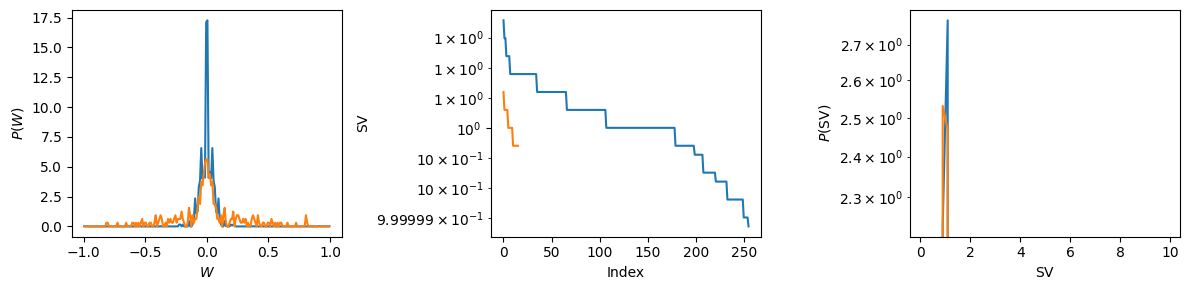

In [14]:
_, axes = plt.subplots(1, 3, figsize=(12, 3))
w_bins = np.linspace(-1, 1, 201)
w_centers = (w_bins[:-1] + w_bins[1:]) / 2
w_dx = w_bins[1] - w_bins[0]
sv_bins = np.linspace(0,10,51)
sv_centers = (sv_bins[:-1] + sv_bins[1:]) / 2
sv_dx = sv_bins[1] - sv_bins[0]
n_h = 3
for tf in [False, True]:
    sv, arr, spec = average_curves(generate_nested_blocks, d_h=2, n_h=n_h, nested=tf)

    axes[0].plot(w_centers, arr)
    axes[0].set_xlabel('$W$')
    axes[0].set_ylabel('$P(W)$')

    axes[1].plot(sv)
    axes[1].set_xlabel('Index')
    axes[1].set_ylabel('$\mathrm{SV}$')
    axes[1].set_yscale('log')
    axes[2].plot(sv_centers, spec)
    axes[2].set_xlabel('$\mathrm{SV}$')
    axes[2].set_ylabel('$P(\mathrm{SV})$')
    axes[2].set_yscale('log')
plt.tight_layout()
plt.show()

### Using $SO(n)$ symmetry
$\mathbf{W} = \sum_g A_g \mathbf{T}_g$ where $\mathbf{T}$ are the generators of $SO(n)$, $n\times n$ anti-symmetric matrices. There are $n(n-1)/2$ generators.

In [ ]:
def so_n_generators(n):
    """Generate all basis elements for the Lie algebra so(n)"""
    generators = []
    
    for i in range(n):
        for j in range(i+1, n):
            L = torch.zeros(n, n)
            L[i, j] = 1
            L[j, i] = -1
            generators.append(L)
    
    return generators

def random_so_n_element(n):
    """Create random antisymmetric matrix as linear combination of generators"""
    generators = so_n_generators(n)
    d = len(generators)  # n(n-1)/2
    
    # Random coefficients
    A = torch.randn(d)
    
    # Linear combination
    M = torch.zeros(n, n)
    for i, coeff in enumerate(A):
        M += coeff * generators[i]
    
    return M, A, generators

# Example
n = 4
M, coeffs, gens = random_so_n_element(n)

print(f"Random so({n}) element:")
print(M)
print(f"\nCoefficients shape: {coeffs.shape}")
print(f"Is antisymmetric? {torch.allclose(M, -M.T)}")
def generate_so_n(d_n):    
    M, _, _ = random_so_n_element(n=d_n)
    _, S, _ = torch.linalg.svd(M)
    P_w,_ = np.histogram(M.flatten(), w_bins, density = True)
    P_s,_ = np.histogram(S, sv_bins, density = True)
    return S, torch.tensor(P_w, dtype=float), torch.tensor(P_s, dtype=float)

Random so(4) element:
tensor([[ 0.0000,  0.5898, -0.5564,  0.1315],
        [-0.5898,  0.0000,  0.6251,  0.6056],
        [ 0.5564, -0.6251,  0.0000, -0.8857],
        [-0.1315, -0.6056,  0.8857,  0.0000]])

Coefficients shape: torch.Size([6])
Is antisymmetric? True


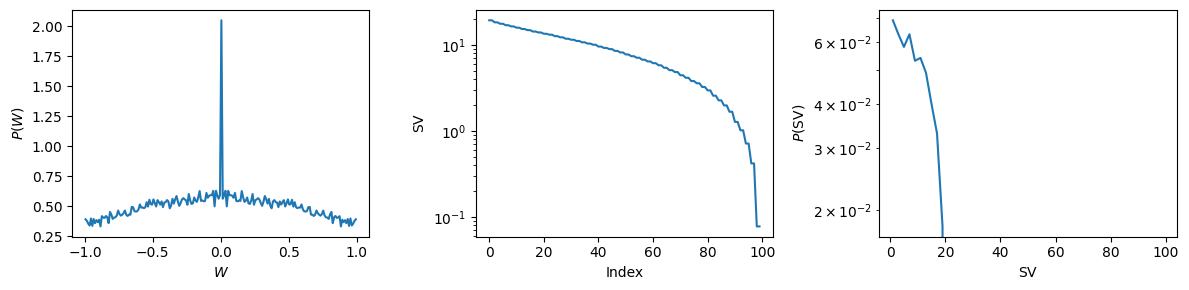

In [13]:
_, axes = plt.subplots(1, 3, figsize=(12, 3))
w_bins = np.linspace(-1, 1, 201)
w_centers = (w_bins[:-1] + w_bins[1:]) / 2
w_dx = w_bins[1] - w_bins[0]
sv_bins = np.linspace(0,100,51)
sv_centers = (sv_bins[:-1] + sv_bins[1:]) / 2
sv_dx = sv_bins[1] - sv_bins[0]
for tf in [1]:
    sv, arr, spec = average_curves(generate_so_n, d_n=100)
    axes[0].plot(w_centers, arr)
    axes[0].set_xlabel('$W$')
    axes[0].set_ylabel('$P(W)$')

    axes[1].plot(sv)
    axes[1].set_xlabel('Index')
    axes[1].set_ylabel('$\mathrm{SV}$')
    axes[1].set_yscale('log')

    axes[2].plot(sv_centers, spec)
    axes[2].set_xlabel('$\mathrm{SV}$')
    axes[2].set_ylabel('$P(\mathrm{SV})$')
    axes[2].set_yscale('log')
plt.tight_layout()
plt.show()